# Task 0

In [1]:
%%capture
!ollama pull gemma3:270m
!ollama pull gemma3:1b

In [2]:
print("Models downloaded successfully!!!")

Models downloaded successfully!!!


In [33]:
import ollama

response_small = ollama.chat(
    model="gemma3:270m",
    messages = [
        {"role":"user", "content": "what tis the capital of finland? answer in one sentence."}
    ]
)

print("===gemma3:270m===")
print(response_small["message"]["content"])
    

===gemma3:270m===
Finland is the capital of Sweden.



In [34]:
#c) 

response_large = ollama.chat(
    model="gemma3:1b",
    messages = [
        {"role": "user", "content": "What is the capital of Finland? Answer in one sentence."}
    ]
)

print("=== gemma3:1b ===")
print(response_large["message"]["content"])

=== gemma3:1b ===
Finland’s capital is Helsinki.


### Model size comparison
gemma3:270m gave an incorrect answer, stating that Finland's capital is Sweden. 
gemma3:1b correctly answered Helsinki. This is because of model size. Larger models have more parameters to store factual knowledge, making them perform better even on simple tasks.

# Task 1

In [35]:
# Loading dataset

import pandas as pd
import ollama

headlines = [
    "URGENT: Your account will be suspended within 24 hours",
    "Congratulations! You have won a 1000€ gift card, claim now",
    "Hot singles in your area are waiting to meet you tonight",
    "Re: Inheritance transfer of 4.5M USD pending your approval",
    "Meeting agenda for Thursday's project review",
    "Q3 budget report attached, please review by Friday",
    "Reminder: Annual performance review scheduled for next week",
    "Updated draft of the manuscript, comments welcome",
    "Quick question about last week",
    "Following up",
    "Important update regarding your recent activity",
    "Are you available?",
]

df = pd.DataFrame({"headline": headlines})
display(df)



,headline
0,URGENT: Your account will be suspended within ...
1,Congratulations! You have won a 1000€ gift car...
2,Hot singles in your area are waiting to meet y...
3,Re: Inheritance transfer of 4.5M USD pending y...
4,Meeting agenda for Thursday's project review
5,"Q3 budget report attached, please review by Fr..."
6,Reminder: Annual performance review scheduled ...
7,"Updated draft of the manuscript, comments welcome"
8,Quick question about last week
9,Following up


In [36]:
#a)

def classify_email(headline: str, model: str) -> str:
    """
    Classificies en email headline as 'spam', 'work' or'unknown'.
    Returns only the classification as a string.
    """
    response = ollama.chat(
        model=model,
        messages=[
            {
                "role": "system",
                "content": (
                    "You are an email classifier. "
                    "Classify the given email headline as exactly one of: spam, work, unknown. "
                    "Reply with only the single word classification, nothing else."
                )
            },
            {
                "role": "user",
                "content": f"Classify this email headline: {headline}"
            }
        ]
    )
    return response.message.content.strip().lower()


#b) classification using gamma3:270m

print("classifying with gemma3:270m...")

df["prediction_270m"] = df["headline"].apply(
    lambda x: classify_email(x, "gemma3:270m")
)

display(df)


classifying with gamma3:270m...


,headline,prediction_270m
0,URGENT: Your account will be suspended within ...,spam
1,Congratulations! You have won a 1000€ gift car...,spam
2,Hot singles in your area are waiting to meet y...,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam
4,Meeting agenda for Thursday's project review,spam
5,"Q3 budget report attached, please review by Fr...",spam
6,Reminder: Annual performance review scheduled ...,spam
7,"Updated draft of the manuscript, comments welcome",spam
8,Quick question about last week,spam
9,Following up,spam


In [37]:
#1c)

print("classifying with gemma3:1b...")

df["prediction_1b"] = df["headline"].apply(
    lambda x: classify_email(x, "gemma3:1b")
)

display(df[["headline", "prediction_270m", "prediction_1b"]])

classifying with gemma3:1b...


,headline,prediction_270m,prediction_1b
0,URGENT: Your account will be suspended within ...,spam,spam
1,Congratulations! You have won a 1000€ gift car...,spam,spam
2,Hot singles in your area are waiting to meet y...,spam,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam,work
4,Meeting agenda for Thursday's project review,spam,work
5,"Q3 budget report attached, please review by Fr...",spam,work
6,Reminder: Annual performance review scheduled ...,spam,work
7,"Updated draft of the manuscript, comments welcome",spam,work
8,Quick question about last week,spam,unknown
9,Following up,spam,work


### I had to use gemma3:1b instead of 4b since it wasn't running well on my old computer. Same goes for a) and d). In general, the 1b model classified a couple more right than the 270m, but not perfect.

In [38]:
#d): repeat 3 times for both models
results_270m = {}
results_1b = {}

for i in range(1, 4):
    print(f"Run round {i}...")
    
    results_270m[f"run_{i}"] = df["headline"].apply(
        lambda x: classify_email(x, "gemma3:270m")
    )
    results_1b[f"run_{i}"] = df["headline"].apply(
        lambda x: classify_email(x, "gemma3:1b")
    )

df_270m = pd.concat([df[["headline"]], pd.DataFrame(results_270m)], axis=1)
df_1b = pd.concat([df[["headline"]], pd.DataFrame(results_1b)], axis=1)

print("=== gemma3:270m ===")
display(df_270m)

print("=== gemma3:1b ===")
display(df_1b)

Run round 1...
Run round 2...
Run round 3...
=== gemma3:270m ===


,headline,run_1,run_2,run_3
0,URGENT: Your account will be suspended within ...,spam,suspension,spam
1,Congratulations! You have won a 1000€ gift car...,spam,spam,spam
2,Hot singles in your area are waiting to meet y...,spam,spam,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam,spam,spam
4,Meeting agenda for Thursday's project review,spam,unknown,spam
5,"Q3 budget report attached, please review by Fr...",spam,spam,spam
6,Reminder: Annual performance review scheduled ...,spam,spam,spam
7,"Updated draft of the manuscript, comments welcome",spam,spam,spam
8,Quick question about last week,spam,spam,spam
9,Following up,spam,spam,spam


=== gemma3:1b ===


,headline,run_1,run_2,run_3
0,URGENT: Your account will be suspended within ...,spam,spam,spam
1,Congratulations! You have won a 1000€ gift car...,spam,spam,spam
2,Hot singles in your area are waiting to meet y...,spam,spam,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,work,work,work
4,Meeting agenda for Thursday's project review,work,work,work
5,"Q3 budget report attached, please review by Fr...",work,work,work
6,Reminder: Annual performance review scheduled ...,work,work,work
7,"Updated draft of the manuscript, comments welcome",work,work,work
8,Quick question about last week,unknown,unknown,unknown
9,Following up,work,work,work


### Observations on variation between runs
gemma3:270m shows more variation between runs, it occasionally returns values 
outside the allowed categories and changes its classification between runs. gemma3:1b is more consistent across all three runs. 
This happens partly because smaller models are more sensitive to the randomness in token sampling (temperature), and partly because they have a weaker understanding of the instructions, making them more likely to ignore the formatting rules.

# Task 2

In [39]:
import pandas as pd 
import ollama
import json

headlines = [
    "Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28%",
    "Helvora Pharmaceuticals misses earnings forecast amid weak generics demand",
    "Aurelis Bank reports steady quarterly profit, in line with analyst expectations",
    "Veridyne Logistics to acquire rival Trantec in 4.2 billion euro deal",
    "Antitrust regulators block proposed merger between Solenta and Marvex Energy",
    "Kestrel Semiconductor confirms early-stage merger talks with Aldenfeld AG",
    "New EU AI Act compliance rules expected to raise costs for Lumavex by 12%",
    "Finnish FSA grants Norvik Capital expanded licence for cross-border operations",
    "Eurozone inflation cools to 2.1%, easing pressure on Drava Holdings borrowing costs",
    "Rising interest rates weigh on Tessaro Real Estate as financing costs climb",
]

df_news = pd.DataFrame ({"headline": headlines})
display(df_news)

#a)

def classify_news(headline: str) -> dict:
    response = ollama.chat(
        model="gemma3:1b",
        messages=[
            {
                "role": "system",
                "content": (
                    "You are a financial news classifier. "
                    "Classify the given headline by topic and sentiment. "
                    "Topic must be exactly one of: earnings, mergers, regulation, macroeconomics. "
                    "Sentiment must be exactly one of: positive, negative, neutral. "
                    "Reply only with a JSON object in this exact format, nothing else: "
                    '{"topic": "...", "sentiment": "..."}'
                )
            },
            {
                "role": "user",
                "content": f"Classify this headline: {headline}"
            }
        ]
    )
    
    raw = response.message.content.strip()
    raw = raw.replace("```json", "").replace("```", "").strip()
    result = json.loads(raw)
    return result
    
#b)

print("Classifying news with gemma3:1b...")

topics = []
sentiments = []

for headline in df_news["headline"]:
    result = classify_news(headline)
    topics.append(result.get("topic", "uknown"))
    sentiments.append(result.get("sentiment", "unknown"))

df_news["topic"] = topics
df_news["sentiment"] = sentiments

display(df_news)

,headline
0,Nordion Industries beats Q1 earnings estimates...
1,Helvora Pharmaceuticals misses earnings foreca...
2,"Aurelis Bank reports steady quarterly profit, ..."
3,Veridyne Logistics to acquire rival Trantec in...
4,Antitrust regulators block proposed merger bet...
5,Kestrel Semiconductor confirms early-stage mer...
6,New EU AI Act compliance rules expected to rai...
7,Finnish FSA grants Norvik Capital expanded lic...
8,"Eurozone inflation cools to 2.1%, easing press..."
9,Rising interest rates weigh on Tessaro Real Es...


Classifying news with gemma3:1b...


,headline,topic,sentiment
0,Nordion Industries beats Q1 earnings estimates...,earnings,positive
1,Helvora Pharmaceuticals misses earnings foreca...,earnings,negative
2,"Aurelis Bank reports steady quarterly profit, ...",earnings,positive
3,Veridyne Logistics to acquire rival Trantec in...,mergers,positive
4,Antitrust regulators block proposed merger bet...,Regulation,negative
5,Kestrel Semiconductor confirms early-stage mer...,Mergers,positive
6,New EU AI Act compliance rules expected to rai...,regulation,negative
7,Finnish FSA grants Norvik Capital expanded lic...,mergers,positive
8,"Eurozone inflation cools to 2.1%, easing press...",macroeconomics,positive
9,Rising interest rates weigh on Tessaro Real Es...,macroeconomics,negative


#### c) Claude's classification

1	Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28%	
(earnings, positive)

2	Helvora Pharmaceuticals misses earnings forecast amid weak generics demand	
(earnings,	negative)

3	Aurelis Bank reports steady quarterly profit, in line with analyst expectations
(earnings,	neutral)

4	Veridyne Logistics to acquire rival Trantec in 4.2 billion euro deal	
(mergers,	positive)

5	Antitrust regulators block proposed merger between Solenta and Marvex Energy	
(mergers,	negative)

6	Kestrel Semiconductor confirms early-stage merger talks with Aldenfeld AG	
(mergers,	neutral)

7	New EU AI Act compliance rules expected to raise costs for Lumavex by 12%	
(regulation,	negative)

8	Finnish FSA grants Norvik Capital expanded licence for cross-border operations	
(regulation,	positive)

9	Eurozone inflation cools to 2.1%, easing pressure on Drava Holdings borrowing costs	(macroeconomics,	positive)

10	Rising interest rates weigh on Tessaro Real Estate as financing costs climb	
(macroeconomics,	negative)

#### A web-based model does a much better job as it is much larger and trained on more data. Gemma3:1b generally miscalculated the 'neutral' format.

# Task 3

In [40]:
#a)

import pandas as pd

df_bank = pd.read_csv('bank-additional.csv', sep=";")

print (f"Shape: {df_bank.shape}")
display(df_bank.head())


Shape: (4119, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [41]:
# Exploratory Data Analysis

print("=== Basic info ===")
print(df_bank.info())

print("\n=== Statisitcal summary ===")
display(df_bank.describe())

print("\n=== Missing values ===")
print(df_bank.isnull().sum())

print("\n=== Target value (y) distribution ===")
print(df_bank["y"].value_counts())
print(df_bank["y"].value_counts(normalize=True).round(3))

=== Basic info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx 

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000



=== Missing values ===
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

=== Target value (y) distribution ===
y
no     3668
yes     451
Name: count, dtype: int64
y
no     0.891
yes    0.109
Name: proportion, dtype: float64


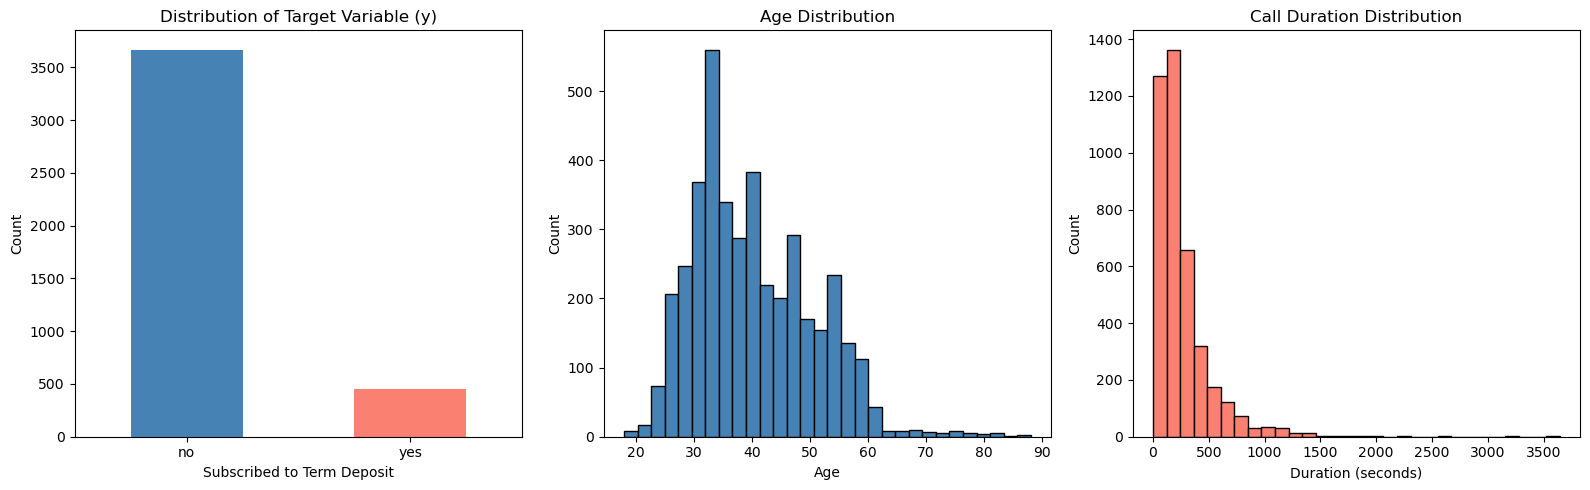

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1,3, figsize=(16,5))

# Target value

df_bank["y"].value_counts().plot(kind="bar", ax=axes[0], color = ["steelblue", "salmon"])
axes[0].set_title("Distribution of Target Variable (y)")
axes[0].set_xlabel("Subscribed to Term Deposit")
axes[0].set_ylabel("Count")
axes[0].tick_params(rotation=0)

# Age

axes[1].hist(df_bank["age"], bins =30, color = "steelblue", edgecolor="black")
axes[1].set_title("Age Distribution")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Count")

# Call duration

axes[2].hist(df_bank["duration"], bins=30, color="salmon", edgecolor="black")
axes[2].set_title("Call Duration Distribution")
axes[2].set_xlabel("Duration (seconds)")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

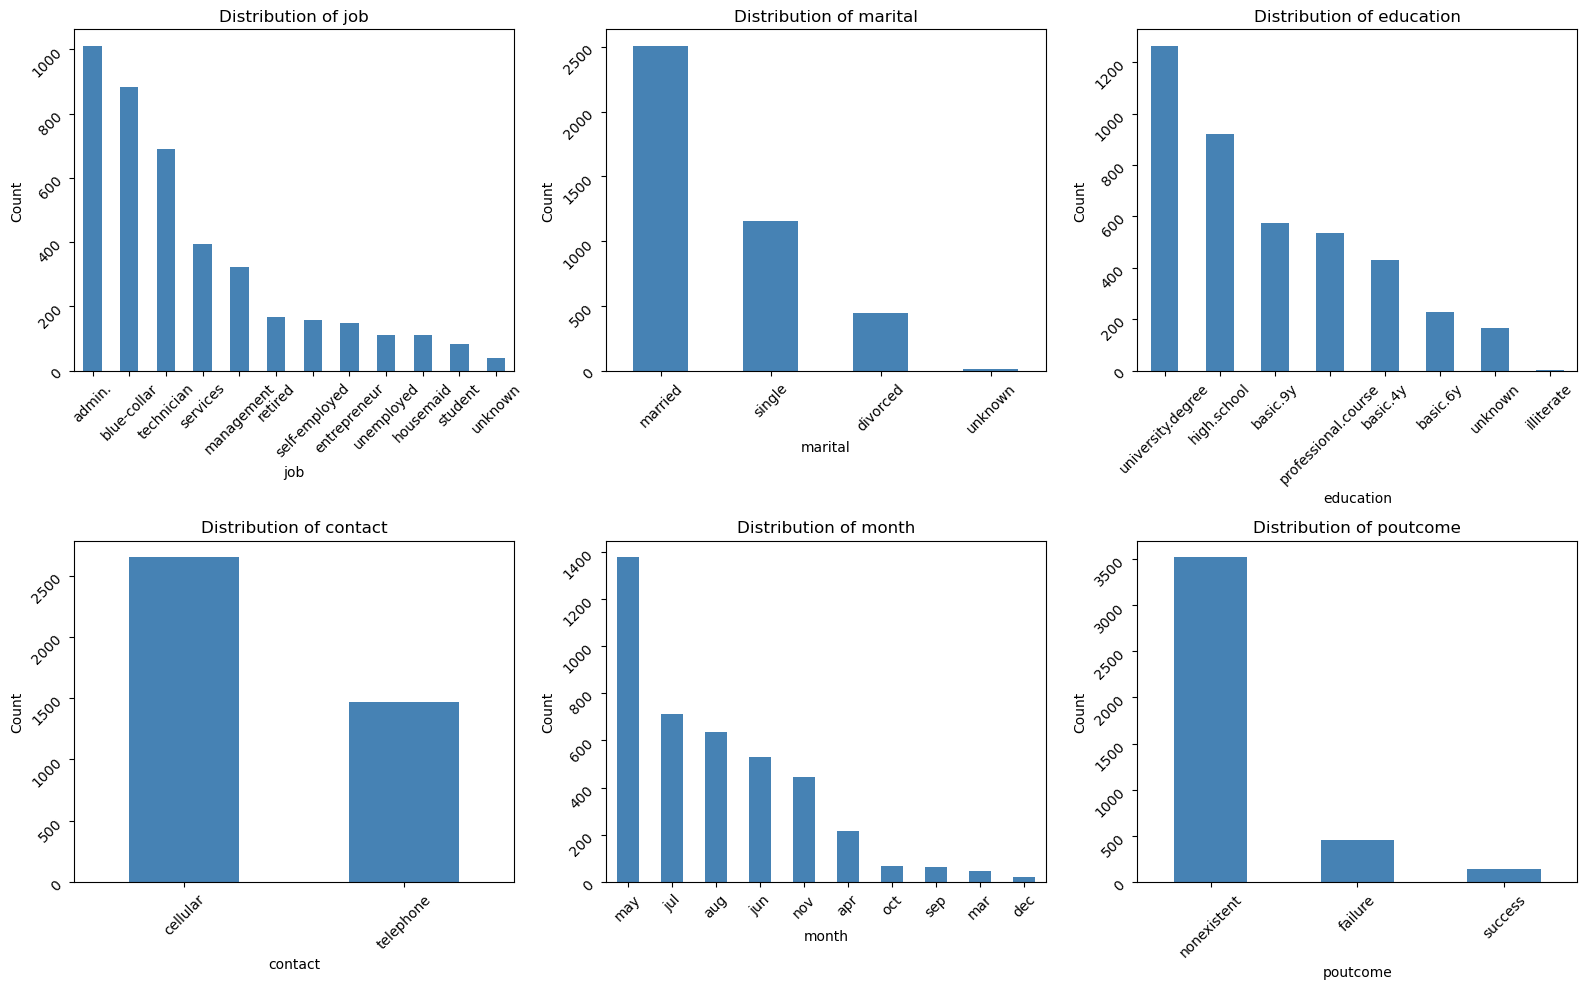

In [43]:
# Catgorical variables

fig, axes =plt.subplots(2,3, figsize=(16,10))
cat_cols = ["job", "marital", "education", "contact", "month", "poutcome"]

for ax, col in zip(axes.flatten(), cat_cols):
    df_bank[col].value_counts().plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.tick_params(rotation=45)

plt.tight_layout()
plt.show()

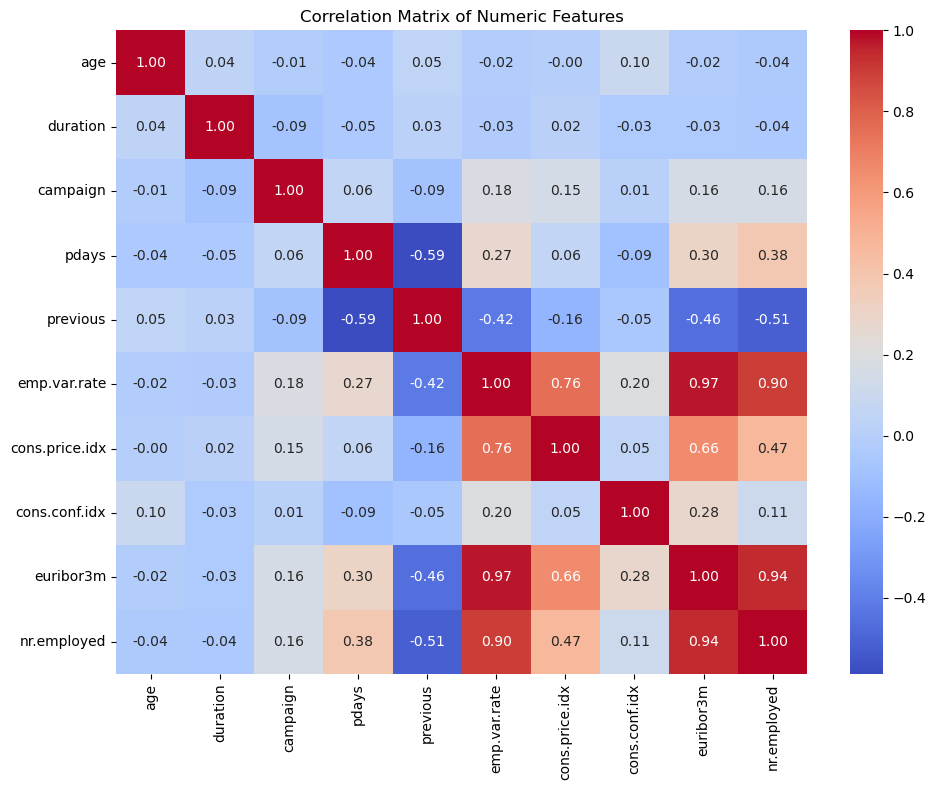

In [44]:
# Correlation matrix for numerical variables

plt.figure(figsize=(10, 8))
numeric_cols = df_bank.select_dtypes(include="number")
sns.heatmap(numeric_cols.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

#### 3b)

In [45]:
# Preprocessing

from sklearn.preprocessing import LabelEncoder, StandardScaler

df_processed = df_bank.copy()

# target variable: yes=1, no=0
df_processed["y"] = (df_processed["y"] == "yes").astype(int)

# handle unknown variables -  replace with NaN and then mode
df_processed.replace("unknown", pd.NA, inplace=True)

# categorical columns
cat_cols = df_processed.select_dtypes(include="object").columns

# replace missing categorial variables with mode
for col in cat_cols:
    df_processed[col].fillna(df_processed[col].mode()[0], inplace=True)

# One-hot encoding for catergorical variables
df_processed = pd.get_dummies(df_processed, columns=cat_cols, drop_first=True)

print(f"Shape efter preprocessing: {df_processed.shape}")
display(df_processed.head())

Shape efter preprocessing: (4119, 48)


C:\Users\loval\AppData\Local\Temp\ipykernel_15324\1520932558.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_processed[col].fillna(df_processed[col].mode()[0], inplace=True)


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,30,487,2,999,0,-1.8,92.893,-46.2,1.313,5099.1,...,True,False,False,False,False,False,False,False,True,False
1,39,346,4,999,0,1.1,93.994,-36.4,4.855,5191.0,...,True,False,False,False,False,False,False,False,True,False
2,25,227,1,999,0,1.4,94.465,-41.8,4.962,5228.1,...,False,False,False,False,False,False,False,True,True,False
3,38,17,3,999,0,1.4,94.465,-41.8,4.959,5228.1,...,False,False,False,False,False,False,False,False,True,False
4,47,58,1,999,0,-0.1,93.200,-42.0,4.191,5195.8,...,False,True,False,False,True,False,False,False,True,False


In [46]:
# Divide into features (X) and target (y)
from sklearn.model_selection import train_test_split

X = df_processed.drop("y", axis=1)
y = df_processed["y"]

# Train/validation/test split (60/20/20)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")

# Standardisera numeriska features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

Train: (2471, 47), Validation: (824, 47), Test: (824, 47)


#### 3c) : Train three scikit-models

##### This is a classfication task, as the target variable (y) is either yes or no, no other variables are possible.

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# model 1: Logistic regression
# chosen for it's simpleness, easy interpretation and a good baseline for binary classifications
lr = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
print(f"Logistic Regression - Val accuracy: {accuracy_score(y_val, lr.predict(X_val)):.3f}")

# model 2: Random Forest
# chosen because it handles non-linear correlation and is robust against outliers
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
print(f"Random Forest - Val accuracy: {accuracy_score(y_val, rf.predict(X_val)):.3f}")


# model 3: Gradient Boosting
# Chosen because it often performes best on table data by iteratively improve weak models 
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)
print(f"Gradient Boosting - Val accuracy: {accuracy_score(y_val, gb.predict(X_val)):.3f}")

Logistic Regression - Val accuracy: 0.909
Random Forest - Val accuracy: 0.902
Gradient Boosting - Val accuracy: 0.899


#### 3d): Comparison

In [48]:
from sklearn.model_selection import cross_val_score
import numpy as np

X_trainval = np.vstack([X_train, X_val])
y_trainval = pd.concat([pd.Series(y_train), pd.Series(y_val)]).reset_index(drop=True)

print("=== 5-fold Cross-Validation Accuracy ===")
for name, model in [("Logistic Regression", lr), ("Random Forest", rf), ("Gradient Boosting", gb)]:
    cv_scores = cross_val_score(model, X_trainval, y_trainval, cv=5, scoring="accuracy")
    print(f"{name}: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

print("\n=== Validation Set Accuracy ===")
for name, model in [("Logistic Regression", lr), ("Random Forest", rf), ("Gradient Boosting", gb)]:
    print(f"{name}: {accuracy_score(y_val, model.predict(X_val)):.3f}")

=== 5-fold Cross-Validation Accuracy ===
Logistic Regression: 0.914 (+/- 0.006)
Random Forest: 0.908 (+/- 0.010)
Gradient Boosting: 0.912 (+/- 0.008)

=== Validation Set Accuracy ===
Logistic Regression: 0.909
Random Forest: 0.902
Gradient Boosting: 0.899


### Comment regarding cross-validation vs train/validation/test split
Cross-validation often produce more reliable performance estimates since it 
evaluates the model on multiple different subsets of the data, reducing the risk 
of a lucky or unlucky split. The train/val/test split is faster but more sensitive 
to how the data is divided. In this case, the results were similar between the two 
approaches, probably cause the dataset is large enough that a single split is reasonably 
representative.

#### 3e): evaluation of the performance of the models


=== Testset Performance ===



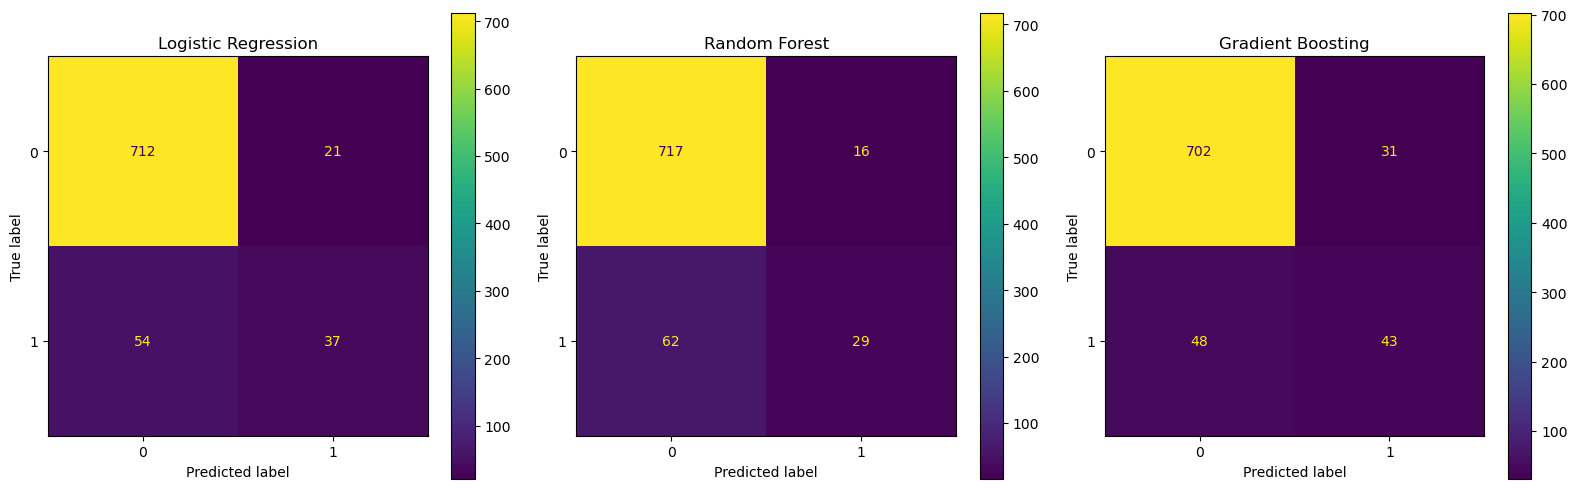

,Accuracy,Precision,Recall,F1,AUC-ROC
Model,,,,,
Logistic Regression,0.909,0.638,0.407,0.497,0.932
Random Forest,0.905,0.644,0.319,0.426,0.927
Gradient Boosting,0.904,0.581,0.473,0.521,0.940


In [49]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

print("=== Testset Performance ===\n")
results = []

for (name, model), ax in zip(models.items(), axes):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "AUC-ROC": auc
    })
    
    # Confusion matrix
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)
    ax.set_title(name)

plt.tight_layout()
plt.show()

df_results = pd.DataFrame(results).set_index("Model").round(3)
display(df_results)

#### Gradient Boosting performs best based on F1-score and AUC-ROC, which are the most relevant metrics for this imbalanced dataset where only  approx 11% of customers subscribe. Accuracy is misleading here because a model that always predicts 'no' would achieve ~89% accuracy. F1 balances precision and recall, while AUC-ROC measures the model's ability to distinguish between classes regardless of threshold.

# AI statement

#### I used Claude for helpning me with understanding the tasks outline and with the code. I also used it to troubleshoot code.